# 03 — Analysis & Visualization

**Project:** Stripped-context A vs trajectory B for next API-call prediction

In [1]:
import json
import os
import pickle
import zipfile
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None
from matplotlib.lines import Line2D

## 1. Load Results

In [2]:
result_candidates = {
    'A': ['artifacts/results_A_seed42.json', '../artifacts/results_A_seed42.json', 'results_A_seed42.json', '../results_A_seed42.json'],
    'B': ['artifacts/results_B_seed42.json', '../artifacts/results_B_seed42.json', 'results_B_seed42.json', '../results_B_seed42.json'],
}

results = {}
for expected_cond, candidates in result_candidates.items():
    loaded = False
    for fname in candidates:
        if not os.path.exists(fname):
            continue
        with open(fname) as f:
            r = json.load(f)
        actual_cond = r.get('condition')
        if actual_cond != expected_cond:
            print(f"WARNING: {fname} expected {expected_cond} but contains {actual_cond}")
        results[actual_cond] = r
        print(f"Loaded: {fname} (condition {actual_cond})")
        loaded = True
        break
    if not loaded:
        print(f"NOT FOUND for {expected_cond}: {candidates}")

print(f"\nConditions loaded: {list(results.keys())}")

Loaded: ../artifacts/results_A_seed42.json (condition A)
Loaded: ../artifacts/results_B_seed42.json (condition B)

Conditions loaded: ['A', 'B']


## 2. Continual Learning Metrics

In [3]:
PRIMARY_MATRIX_KEY = 'eval_full_acc'
PRIMARY_ZS_KEY = 'full_acc'
SECONDARY_MATRIX_KEY = 'eval_acc'
SECONDARY_ZS_KEY = 'name_acc'

def compute_cl_metrics(result, matrix_key=PRIMARY_MATRIX_KEY, zero_shot_key=PRIMARY_ZS_KEY):
    acc = np.array(result[matrix_key])
    n = acc.shape[0]

    aa = np.mean(acc[-1, :])
    bwt = np.mean([acc[-1, j] - acc[j, j] for j in range(n - 1)]) if n > 1 else 0.0

    zs = result.get('zero_shot', {}).get(zero_shot_key, [])
    fwt_terms = [acc[j - 1, j] - zs[j] for j in range(1, n) if len(zs) > j]
    fwt = np.mean(fwt_terms) if fwt_terms else 0.0

    forgetting = []
    for j in range(n - 1):
        best = max(acc[i, j] for i in range(j, n))
        forgetting.append(best - acc[-1, j])
    avg_forgetting = np.mean(forgetting) if forgetting else 0.0

    aulc_vals = []
    for j in range(n):
        curve = [acc[i, j] for i in range(j, n)]
        if len(curve) > 1:
            aulc = np.trapz(curve, dx=1.0) / (len(curve) - 1)
        else:
            aulc = curve[0]
        aulc_vals.append(aulc)
    avg_aulc = np.mean(aulc_vals)

    return {
        'Average Accuracy (AA)': aa,
        'Backward Transfer (BWT)': bwt,
        'Forward Transfer (FWT)': fwt,
        'Average Forgetting': avg_forgetting,
        'Average AULC': avg_aulc,
    }

all_metrics = {}
name_metrics = {}
for cond, r in results.items():
    primary = compute_cl_metrics(r, PRIMARY_MATRIX_KEY, PRIMARY_ZS_KEY)
    secondary = compute_cl_metrics(r, SECONDARY_MATRIX_KEY, SECONDARY_ZS_KEY)
    all_metrics[cond] = primary
    name_metrics[cond] = secondary

    print(f"\nCondition {cond} (primary = exact full-call):")
    for k, v in primary.items():
        print(f"  {k}: {v:.4f}")

    print(f"Condition {cond} (secondary = exact API name):")
    for k, v in secondary.items():
        print(f"  {k}: {v:.4f}")



Condition A (primary = exact full-call):
  Average Accuracy (AA): 0.3594
  Backward Transfer (BWT): -0.1250
  Forward Transfer (FWT): 0.2292
  Average Forgetting: 0.1250
  Average AULC: 0.4082
Condition A (secondary = exact API name):
  Average Accuracy (AA): 0.6250
  Backward Transfer (BWT): -0.2292
  Forward Transfer (FWT): 0.3542
  Average Forgetting: 0.2292
  Average AULC: 0.6934

Condition B (primary = exact full-call):
  Average Accuracy (AA): 0.5703
  Backward Transfer (BWT): -0.0938
  Forward Transfer (FWT): 0.3021
  Average Forgetting: 0.0938
  Average AULC: 0.5957
Condition B (secondary = exact API name):
  Average Accuracy (AA): 0.7734
  Backward Transfer (BWT): -0.0521
  Forward Transfer (FWT): 0.1354
  Average Forgetting: 0.0729
  Average AULC: 0.7975


/var/folders/sx/nc8w_xhx3kn25kk_v0kljfyw0000gn/T/ipykernel_3865/2315033988.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aulc = np.trapz(curve, dx=1.0) / (len(curve) - 1)


## 3. Summary Table

In [4]:
conds = sorted(results.keys())
metric_keys = [
    'Average Accuracy (AA)',
    'Backward Transfer (BWT)',
    'Forward Transfer (FWT)',
    'Average Forgetting',
    'Average AULC',
]

print("=" * 80)
print("CONTINUAL LEARNING METRICS")
print("=" * 80)
header = f"{'Metric':<28}" + "".join(f"{c:>16}" for c in conds)
print(header)
print("-" * (28 + 16 * len(conds)))
for key in metric_keys:
    row = f"{key:<28}"
    for c in conds:
        row += f"{all_metrics[c][key]:>16.4f}"
    print(row)

CONTINUAL LEARNING METRICS
Metric                                     A               B
------------------------------------------------------------
Average Accuracy (AA)                 0.3594          0.5703
Backward Transfer (BWT)              -0.1250         -0.0938
Forward Transfer (FWT)                0.2292          0.3021
Average Forgetting                    0.1250          0.0938
Average AULC                          0.4082          0.5957


In [5]:
# Full evaluation matrices
for cond in conds:
    r = results[cond]
    n = len(r[PRIMARY_MATRIX_KEY])
    print(f"\n{'=' * 72}")
    print(f"EVAL MATRIX — Condition {cond} (Exact Full-Call Accuracy)")
    print(f"{'=' * 72}")
    print(f"{'':>14}", end="")
    for j in range(n):
        print(f"{'D' + str(j+1):>10}", end="")
    print()
    for i in range(n):
        print(f"After D{i+1}:    ", end="")
        for j in range(n):
            print(f"{r[PRIMARY_MATRIX_KEY][i][j]:>10.1%}", end="")
        print()



EVAL MATRIX — Condition A (Exact Full-Call Accuracy)
                      D1        D2        D3        D4
After D1:         50.0%     40.6%     31.2%      9.4%
After D2:         43.8%     50.0%     31.2%      9.4%
After D3:         40.6%     46.9%     40.6%     18.8%
After D4:         34.4%     40.6%     28.1%     40.6%

EVAL MATRIX — Condition B (Exact Full-Call Accuracy)
                      D1        D2        D3        D4
After D1:         62.5%     59.4%     50.0%     43.8%
After D2:         59.4%     59.4%     53.1%     50.0%
After D3:         50.0%     56.2%     59.4%     46.9%
After D4:         56.2%     56.2%     40.6%     75.0%


## 4. Visualizations

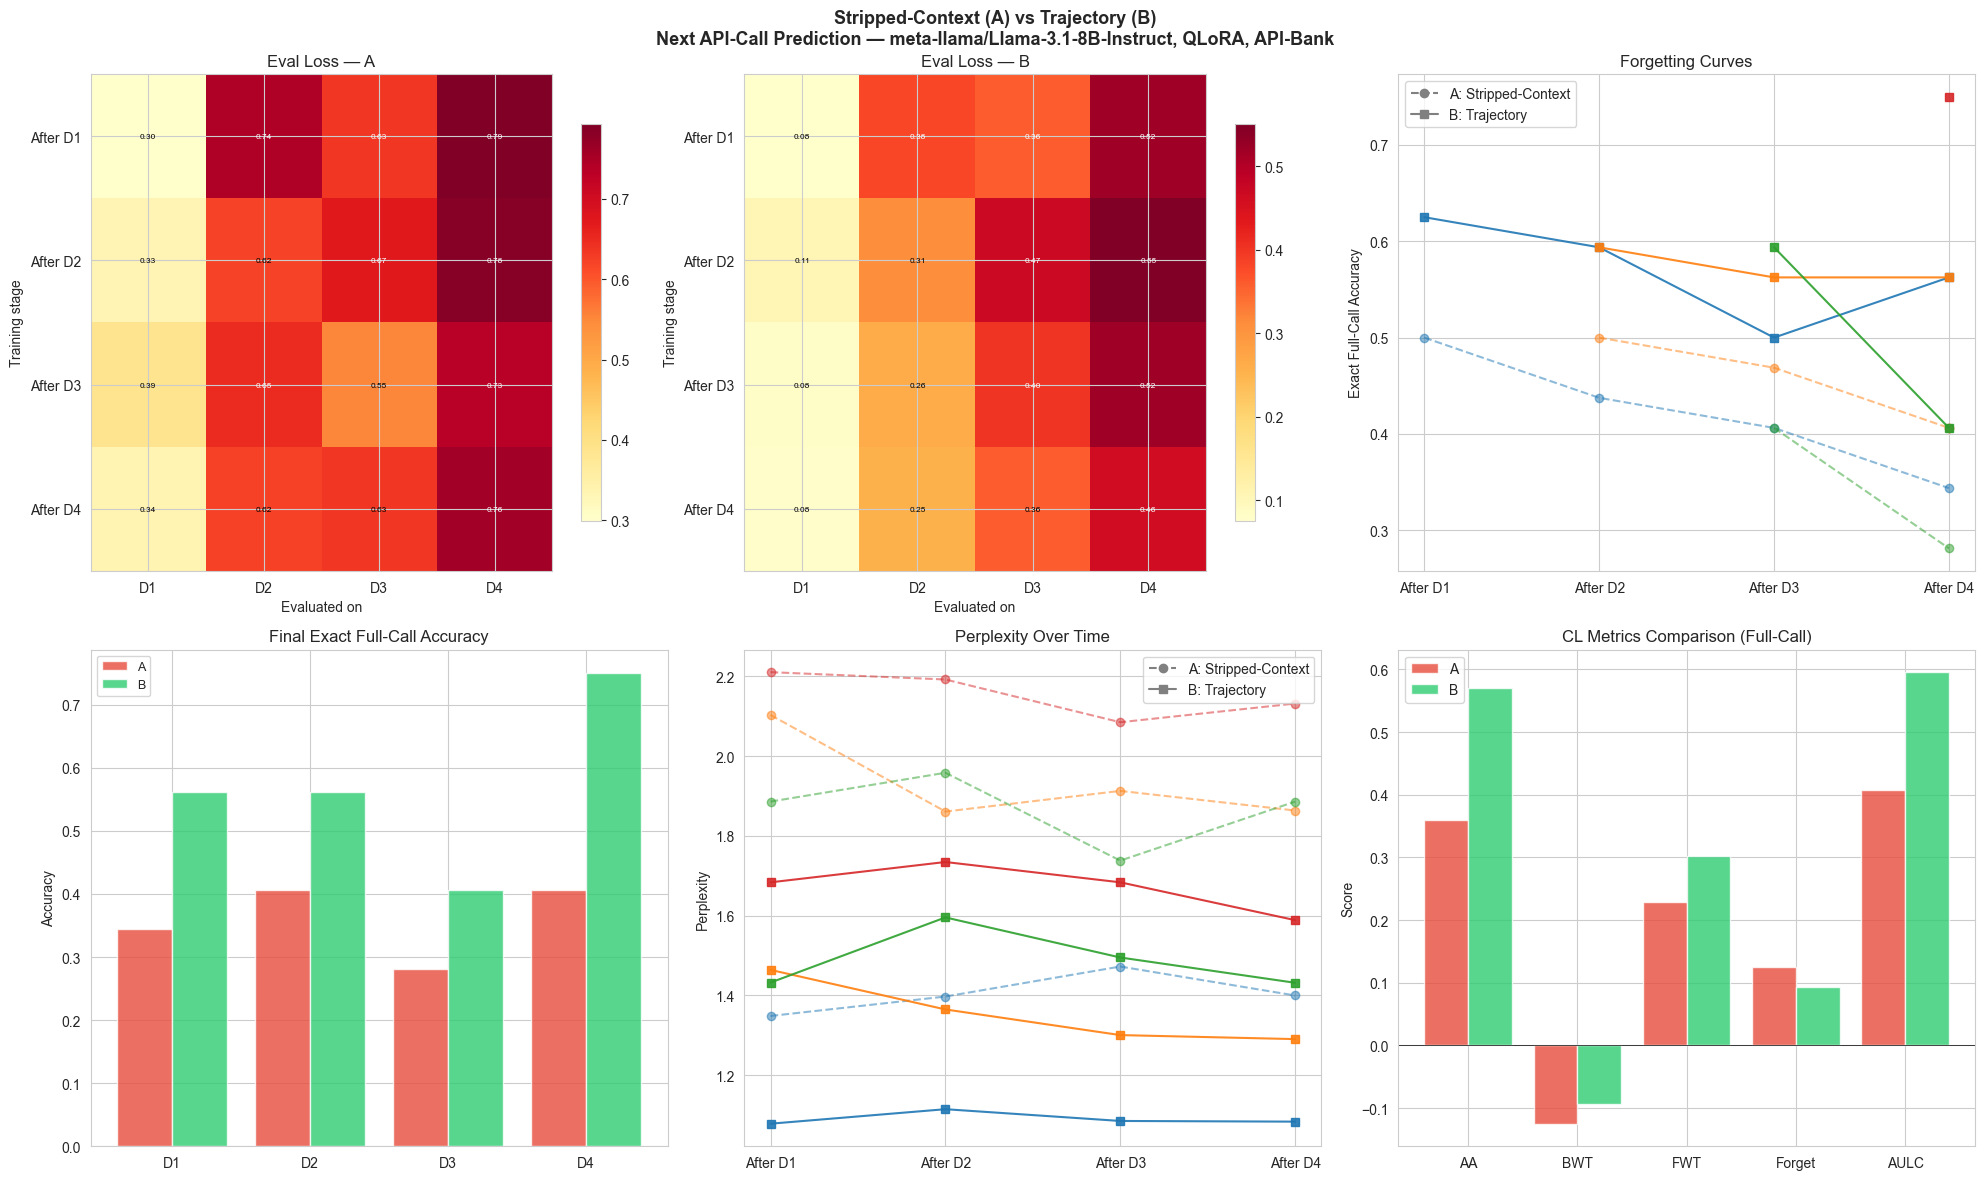

Saved: final_results.png, final_results.pdf


In [6]:
if sns is not None:
    sns.set_style("whitegrid")
else:
    plt.style.use('default')
model_label = next(iter(results.values())).get('config', {}).get('model', 'model') if results else 'model'
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "Stripped-Context (A) vs Trajectory (B)\n"
    f"Next API-Call Prediction — {model_label}, QLoRA, API-Bank",
    fontsize=13, fontweight='bold',
)

n = len(list(results.values())[0][PRIMARY_MATRIX_KEY])
blabels = [f'D{i+1}' for i in range(n)]
colors = {'A': '#e74c3c', 'B': '#2ecc71'}

# Plot 1 & 2: Loss Heatmaps
for idx, cond in enumerate(['A', 'B']):
    if cond not in results:
        continue
    ax = axes[0, idx]
    data = np.array(results[cond]['eval_loss'])
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(blabels)
    ax.set_yticklabels([f'After {l}' for l in blabels])
    ax.set_xlabel("Evaluated on"); ax.set_ylabel("Training stage")
    ax.set_title(f"Eval Loss — {cond}")
    for i in range(n):
        for j in range(n):
            c = 'white' if data[i,j] > np.median(data) else 'black'
            ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color=c)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Plot 3: Forgetting Curves
ax = axes[0, 2]
for cond in ['A', 'B']:
    if cond not in results:
        continue
    acc = np.array(results[cond][PRIMARY_MATRIX_KEY])
    for j in range(n):
        stages = list(range(j, n))
        vals = [acc[i, j] for i in stages]
        style = 'o--' if cond == 'A' else 's-'
        alpha = 0.5 if cond == 'A' else 0.9
        ax.plot(stages, vals, style, color=f'C{j}', alpha=alpha)
ax.set_xticks(range(n))
ax.set_xticklabels([f'After {l}' for l in blabels])
ax.set_ylabel("Exact Full-Call Accuracy"); ax.set_title("Forgetting Curves")
legend_lines = [
    Line2D([0],[0], linestyle='--', marker='o', color='gray'),
    Line2D([0],[0], linestyle='-', marker='s', color='gray'),
]
ax.legend(legend_lines, ['A: Stripped-Context', 'B: Trajectory'])

# Plot 4: Final Accuracy
ax = axes[1, 0]
x = np.arange(n)
w = 0.8 / len(conds)
for ci, cond in enumerate(conds):
    vals = np.array(results[cond][PRIMARY_MATRIX_KEY])[-1]
    ax.bar(x + ci*w - 0.4 + w/2, vals, w,
           label=cond, color=colors.get(cond, 'gray'), alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(blabels)
ax.set_ylabel("Accuracy"); ax.set_title("Final Exact Full-Call Accuracy")
ax.legend(fontsize=9)

# Plot 5: Perplexity
ax = axes[1, 1]
for cond in ['A', 'B']:
    if cond not in results:
        continue
    ppl = np.array(results[cond]['eval_ppl'])
    for j in range(n):
        style = 'o--' if cond == 'A' else 's-'
        alpha = 0.5 if cond == 'A' else 0.9
        ax.plot(range(n), [ppl[i,j] for i in range(n)],
                style, color=f'C{j}', alpha=alpha)
ax.set_xticks(range(n))
ax.set_xticklabels([f'After {l}' for l in blabels])
ax.set_ylabel("Perplexity"); ax.set_title("Perplexity Over Time")
ax.legend(legend_lines, ['A: Stripped-Context', 'B: Trajectory'])

# Plot 6: CL Metrics
ax = axes[1, 2]
short_names = ['AA', 'BWT', 'FWT', 'Forget', 'AULC']
x = np.arange(len(metric_keys))
w = 0.8 / len(conds)
for ci, cond in enumerate(conds):
    vals = [all_metrics[cond][k] for k in metric_keys]
    ax.bar(x + ci*w - 0.4 + w/2, vals, w,
           label=cond, color=colors.get(cond, 'gray'), alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("Score"); ax.set_title("CL Metrics Comparison (Full-Call)")
ax.legend(); ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.savefig('final_results.pdf', bbox_inches='tight')
plt.show()
print("Saved: final_results.png, final_results.pdf")


## 5. Zero-Shot Baseline

In [7]:
print("ZERO-SHOT BASELINE")
print("-" * 60)
for cond in conds:
    r = results[cond]
    zs = r.get('zero_shot', {})
    if not zs or not zs.get('name_acc'):
        continue
    print(f"\n  Condition {cond}:")
    for j in range(len(zs['name_acc'])):
        print(f"    D{j+1}: name={zs['name_acc'][j]:.1%}, "
              f"full={zs['full_acc'][j]:.1%}, "
              f"loss={zs['loss'][j]:.3f}")

ZERO-SHOT BASELINE
------------------------------------------------------------

  Condition A:
    D1: name=21.9%, full=12.5%, loss=1.545
    D2: name=28.1%, full=15.6%, loss=1.867
    D3: name=9.4%, full=0.0%, loss=1.805
    D4: name=12.5%, full=6.2%, loss=1.864

  Condition B:
    D1: name=68.8%, full=31.2%, loss=0.538
    D2: name=84.4%, full=37.5%, loss=0.941
    D3: name=62.5%, full=15.6%, loss=1.152
    D4: name=53.1%, full=15.6%, loss=1.087


## 6. Token Budget Analysis

In [8]:
def load_preprocessed_data():
    candidates_pkl = ['preprocessed_data/preprocessed.pkl', '../preprocessed_data/preprocessed.pkl']
    for pkl_path in candidates_pkl:
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                return pickle.load(f)

    candidates_zip = ['artifacts/preprocessed_data.zip', '../artifacts/preprocessed_data.zip']
    for zip_path in candidates_zip:
        if os.path.exists(zip_path):
            with zipfile.ZipFile(zip_path) as zf:
                with zf.open('preprocessed.pkl') as f:
                    return pickle.load(f)
    return None

def get_total_train_tokens(result):
    if 'total_train_tokens' in result:
        return result['total_train_tokens']
    data = load_preprocessed_data()
    if data is None:
        return None
    blocks = data['blocks'][:len(result[PRIMARY_MATRIX_KEY])]
    if result['condition'] == 'A':
        return sum(b['train_tokens_a'] for b in blocks)
    if result['condition'] == 'B':
        return sum(b['train_tokens_b'] for b in blocks)
    return None

print("TOKEN BUDGET ANALYSIS")
print("=" * 60)
print("Primary CL metric source: exact full-call accuracy.")

token_totals = {cond: get_total_train_tokens(result) for cond, result in results.items()}
for cond in conds:
    if cond not in all_metrics:
        continue
    aa = all_metrics[cond]['Average Accuracy (AA)']
    tokens = token_totals.get(cond)
    print(f"\n{cond}: AA = {aa:.4f}")
    if tokens is not None:
        print(f"  train tokens = {tokens:,}")
        print(f"  AA per 1M train tokens = {aa / (tokens / 1_000_000):.4f}")

if 'A' in all_metrics and 'B' in all_metrics:
    aa_a = all_metrics['A']['Average Accuracy (AA)']
    aa_b = all_metrics['B']['Average Accuracy (AA)']
    gap_raw = aa_b - aa_a
    print(f"\nRaw gap (B - A): {gap_raw:+.4f}")
    tokens_a = token_totals.get('A')
    tokens_b = token_totals.get('B')
    if tokens_a is not None and tokens_b is not None:
        ratio = tokens_b / tokens_a if tokens_a > 0 else float('inf')
        print(f"Token ratio (B / A): {ratio:.3f}x")

    print(f"\nPer-block final exact full-call accuracy:")
    acc_a = np.array(results['A'][PRIMARY_MATRIX_KEY])[-1]
    acc_b = np.array(results['B'][PRIMARY_MATRIX_KEY])[-1]
    for j in range(len(acc_a)):
        diff = acc_b[j] - acc_a[j]
        print(f"  D{j+1}: A={acc_a[j]:.1%}, B={acc_b[j]:.1%}, diff={diff:+.1%}")

TOKEN BUDGET ANALYSIS
Primary CL metric source: exact full-call accuracy.

A: AA = 0.3594
  train tokens = 1,857,169
  AA per 1M train tokens = 0.1935

B: AA = 0.5703
  train tokens = 2,324,314
  AA per 1M train tokens = 0.2454

Raw gap (B - A): +0.2109
Token ratio (B / A): 1.252x

Per-block final exact full-call accuracy:
  D1: A=34.4%, B=56.2%, diff=+21.9%
  D2: A=40.6%, B=56.2%, diff=+15.6%
  D3: A=28.1%, B=40.6%, diff=+12.5%
  D4: A=40.6%, B=75.0%, diff=+34.4%


## 7. Export

In [9]:
analysis = {
    'metrics': {c: m for c, m in all_metrics.items()},
    'conditions': list(results.keys()),
}
for cond, r in results.items():
    analysis[f'eval_full_acc_{cond}'] = r['eval_full_acc']
    analysis[f'eval_name_acc_{cond}'] = r['eval_acc']
    analysis[f'zero_shot_{cond}'] = r.get('zero_shot', {})
    analysis[f'total_train_tokens_{cond}'] = get_total_train_tokens(r)

with open('analysis_results.json', 'w') as f:
    json.dump(analysis, f, indent=2, default=str)

print("Saved: analysis_results.json")
print("\nFiles for paper:")
print("  final_results.png / .pdf")
print("  analysis_results.json")

Saved: analysis_results.json

Files for paper:
  final_results.png / .pdf
  analysis_results.json
